In [8]:
import pandas as pd

df = pd.read_csv('../data/high_diamond_ranked_10min.csv')

df['blueKDA'] = (df['blueKills'] + df['blueAssists']) / (df['blueDeaths'] + 1)
df['redKDA'] = (df['redKills'] + df['redAssists']) / (df['redDeaths'] + 1)

df['blueTotalObjectives'] = df['blueDragons'] + df['blueHeralds'] + df['blueTowersDestroyed']
df['redTotalObjectives'] = df['redDragons'] + df['redHeralds'] + df['redTowersDestroyed']

df['blueGoldPerKill'] = df['blueTotalGold'] / (df['blueKills'] + 1)
df['redGoldPerKill'] = df['redTotalGold'] / (df['redKills'] + 1)

df['blueXPPerMin'] = df['blueTotalExperience'] / 10
df['redXPPerMin'] = df['redTotalExperience'] / 10

df['blueSnowballFactor'] = df['blueGoldDiff'] / (df['blueKills'] + 1)
df['redSnowballFactor'] = df['redGoldDiff'] / (df['redKills'] + 1)

(9879, 50)
0
blueWins
0    0.500962
1    0.499038
Name: proportion, dtype: float64


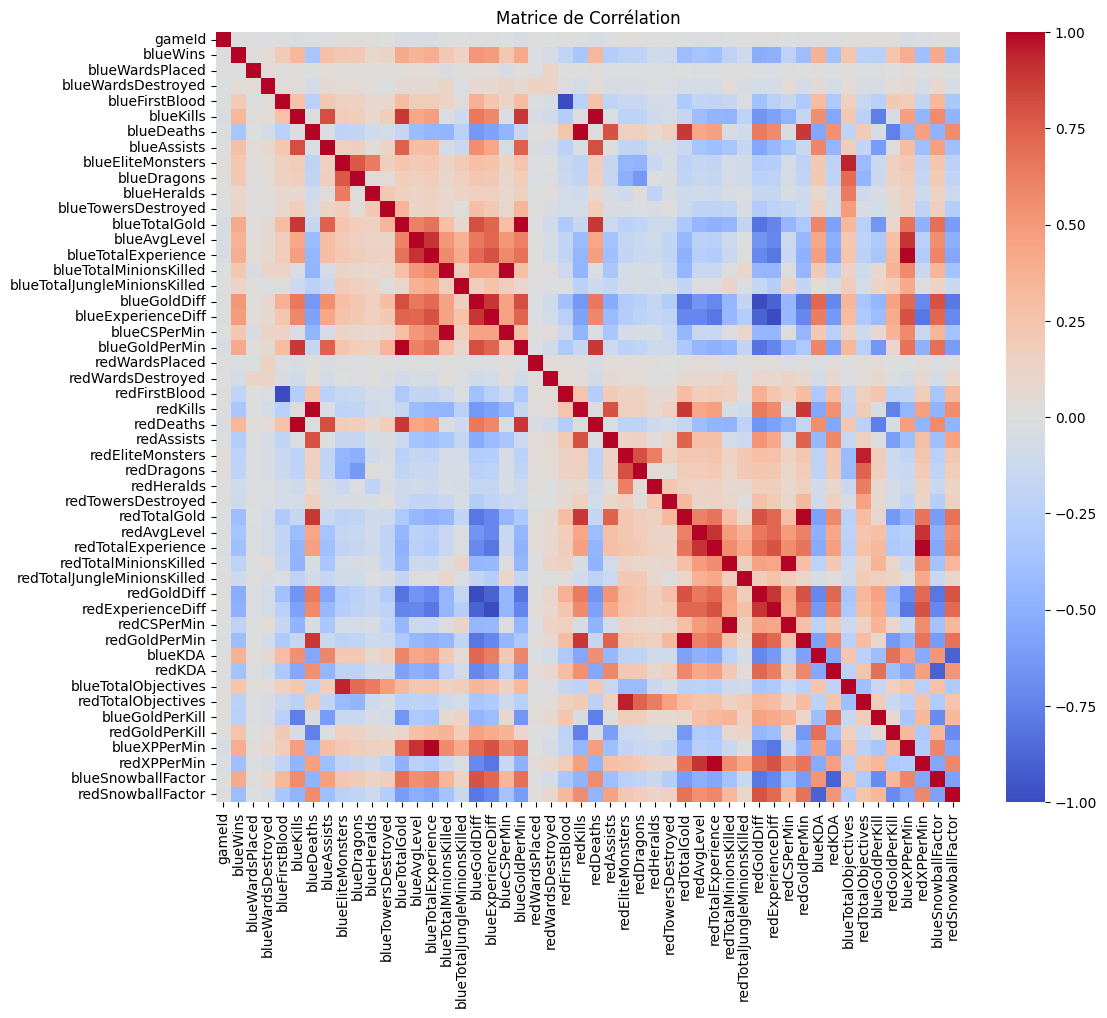

C:\Users\miche\AppData\Local\Temp\ipykernel_11948\966334959.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_corr.head(10).values, y=target_corr.head(10).index, palette='viridis')


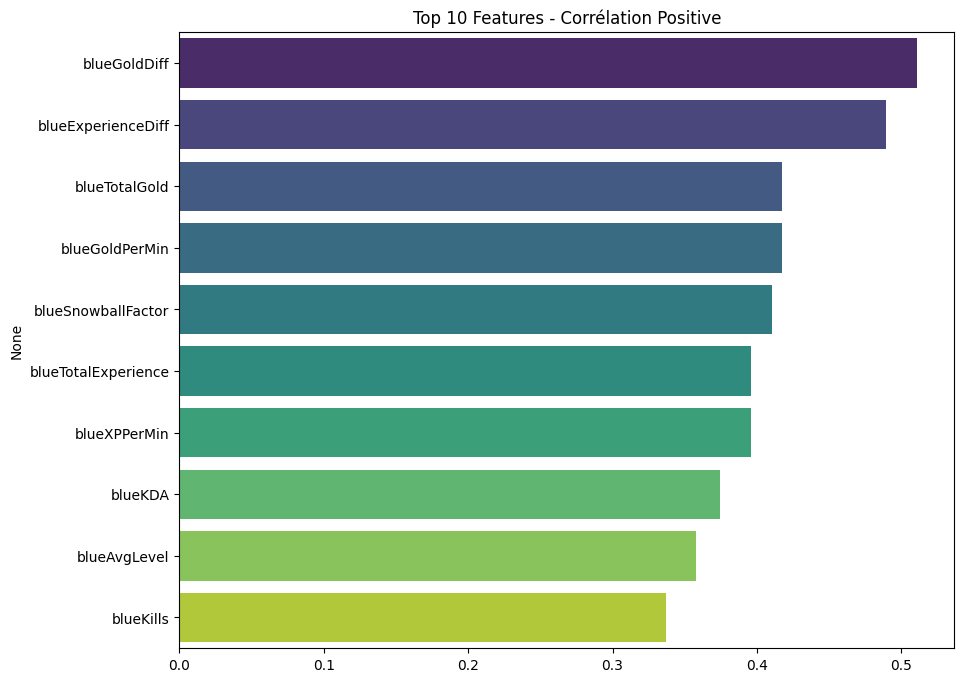

C:\Users\miche\AppData\Local\Temp\ipykernel_11948\966334959.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_corr.tail(10).values, y=target_corr.tail(10).index, palette='magma')


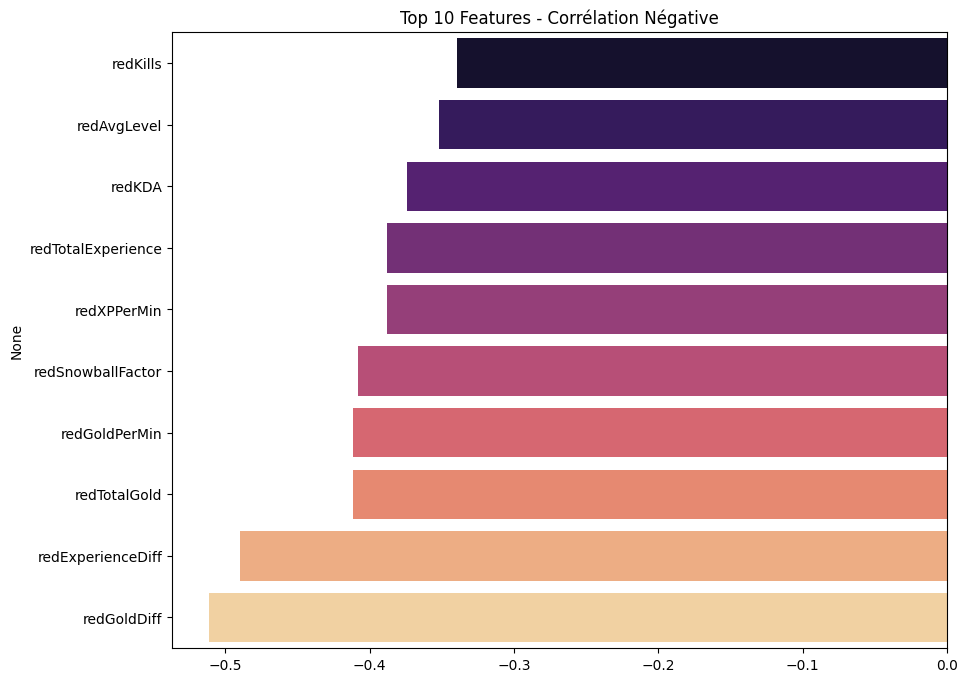

C:\Users\miche\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\xgboost\training.py:200: UserWarning: [10:55:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


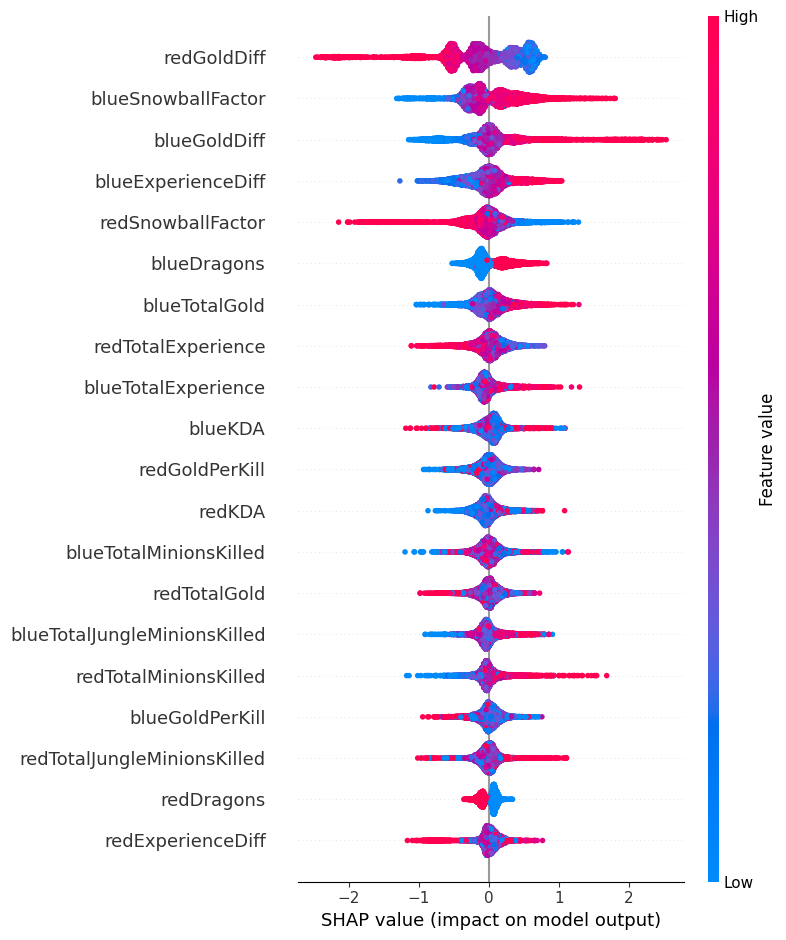

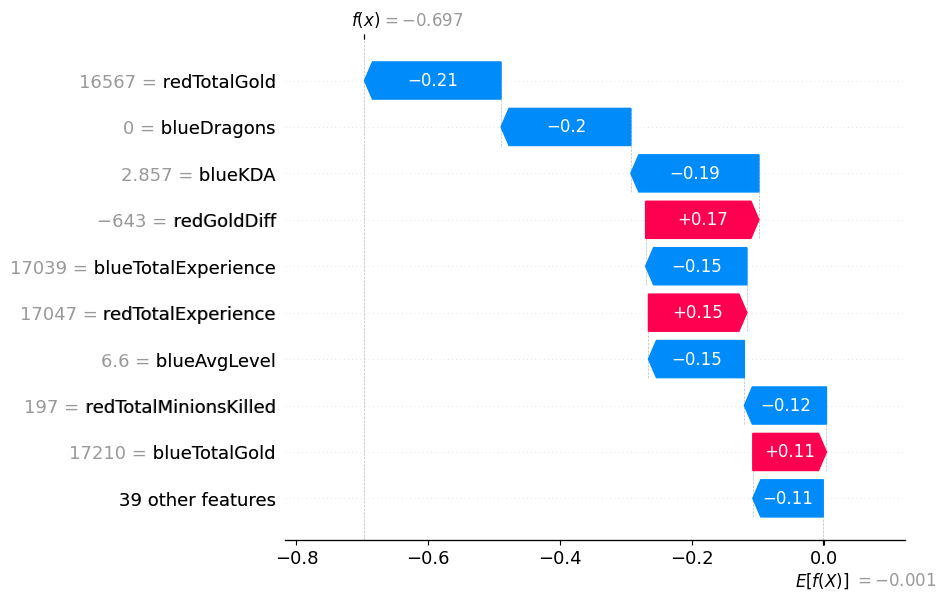

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap

print(df.shape)
print(df.isnull().sum().sum())
print(df['blueWins'].value_counts(normalize=True))

plt.figure(figsize=(12, 10))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Matrice de Corrélation')
plt.show()

target_corr = corr['blueWins'].drop(['blueWins', 'gameId']).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=target_corr.head(10).values, y=target_corr.head(10).index, palette='viridis')
plt.title('Top 10 Features - Corrélation Positive')
plt.show()

plt.figure(figsize=(10, 8))
sns.barplot(x=target_corr.tail(10).values, y=target_corr.tail(10).index, palette='magma')
plt.title('Top 10 Features - Corrélation Négative')
plt.show()

X = df.drop(columns=['gameId', 'blueWins'])
y = df['blueWins']

model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
model.fit(X, y)

explainer = shap.TreeExplainer(model)
shap_values = explainer(X)

shap.summary_plot(shap_values, X)

shap.plots.waterfall(shap_values[0], max_display=10)

In [10]:
df.columns

Index(['gameId', 'blueWins', 'blueWardsPlaced', 'blueWardsDestroyed',
       'blueFirstBlood', 'blueKills', 'blueDeaths', 'blueAssists',
       'blueEliteMonsters', 'blueDragons', 'blueHeralds',
       'blueTowersDestroyed', 'blueTotalGold', 'blueAvgLevel',
       'blueTotalExperience', 'blueTotalMinionsKilled',
       'blueTotalJungleMinionsKilled', 'blueGoldDiff', 'blueExperienceDiff',
       'blueCSPerMin', 'blueGoldPerMin', 'redWardsPlaced', 'redWardsDestroyed',
       'redFirstBlood', 'redKills', 'redDeaths', 'redAssists',
       'redEliteMonsters', 'redDragons', 'redHeralds', 'redTowersDestroyed',
       'redTotalGold', 'redAvgLevel', 'redTotalExperience',
       'redTotalMinionsKilled', 'redTotalJungleMinionsKilled', 'redGoldDiff',
       'redExperienceDiff', 'redCSPerMin', 'redGoldPerMin', 'blueKDA',
       'redKDA', 'blueTotalObjectives', 'redTotalObjectives',
       'blueGoldPerKill', 'redGoldPerKill', 'blueXPPerMin', 'redXPPerMin',
       'blueSnowballFactor', 'redSnowballFa

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score

df['blueKDA'] = (df['blueKills'] + df['blueAssists']) / (df['blueDeaths'] + 1)
df['redKDA'] = (df['redKills'] + df['redAssists']) / (df['redDeaths'] + 1)
df['blueTotalObjectives'] = df['blueDragons'] + df['blueHeralds'] + df['blueTowersDestroyed']
df['redTotalObjectives'] = df['redDragons'] + df['redHeralds'] + df['redTowersDestroyed']
df['blueGoldPerKill'] = df['blueTotalGold'] / (df['blueKills'] + 1)
df['redGoldPerKill'] = df['redTotalGold'] / (df['redKills'] + 1)
df['blueXPPerMin'] = df['blueTotalExperience'] / 10
df['redXPPerMin'] = df['redTotalExperience'] / 10
df['blueSnowballFactor'] = df['blueGoldDiff'] / (df['blueKills'] + 1)
df['redSnowballFactor'] = df['redGoldDiff'] / (df['redKills'] + 1)

X = df.drop(columns=['gameId', 'blueWins'])
y = df['blueWins']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("KNN F1-Score:", f1_score(y_test, y_pred_knn))

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("Logistic Regression F1-Score:", f1_score(y_test, y_pred_log))

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("XGBoost F1-Score:", f1_score(y_test, y_pred_xgb))

C:\Users\miche\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\xgboost\training.py:200: UserWarning: [10:58:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


KNN Accuracy: 0.687246963562753
KNN F1-Score: 0.6881937436932392
Logistic Regression Accuracy: 0.7176113360323887
Logistic Regression F1-Score: 0.721
XGBoost Accuracy: 0.7029352226720648
XGBoost F1-Score: 0.702181633688483


In [13]:
pip install statsmodels

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 352.2 kB/s eta 0:00:26
   -- ------------------------------------- 0.5/9.5 MB 352.2 kB/s eta 0:00:26
   -- -


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\miche\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


C:\Users\miche\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Valeurs VIF pour chaque feature :
                   Feature  VIF
0                blueKills  inf
1              blueDragons  inf
2        blueEliteMonsters  inf
3               blueDeaths  inf
4      blueTotalExperience  inf
5            blueTotalGold  inf
6      blueTowersDestroyed  inf
7              blueHeralds  inf
8             blueGoldDiff  inf
9   blueTotalMinionsKilled  inf
10              redHeralds  inf
11                redKills  inf
12               redDeaths  inf
13          blueGoldPerMin  inf
14            blueCSPerMin  inf
15      blueExperienceDiff  inf
16            blueXPPerMin  inf
17             redXPPerMin  inf
18      redTotalObjectives  inf
19     blueTotalObjectives  inf


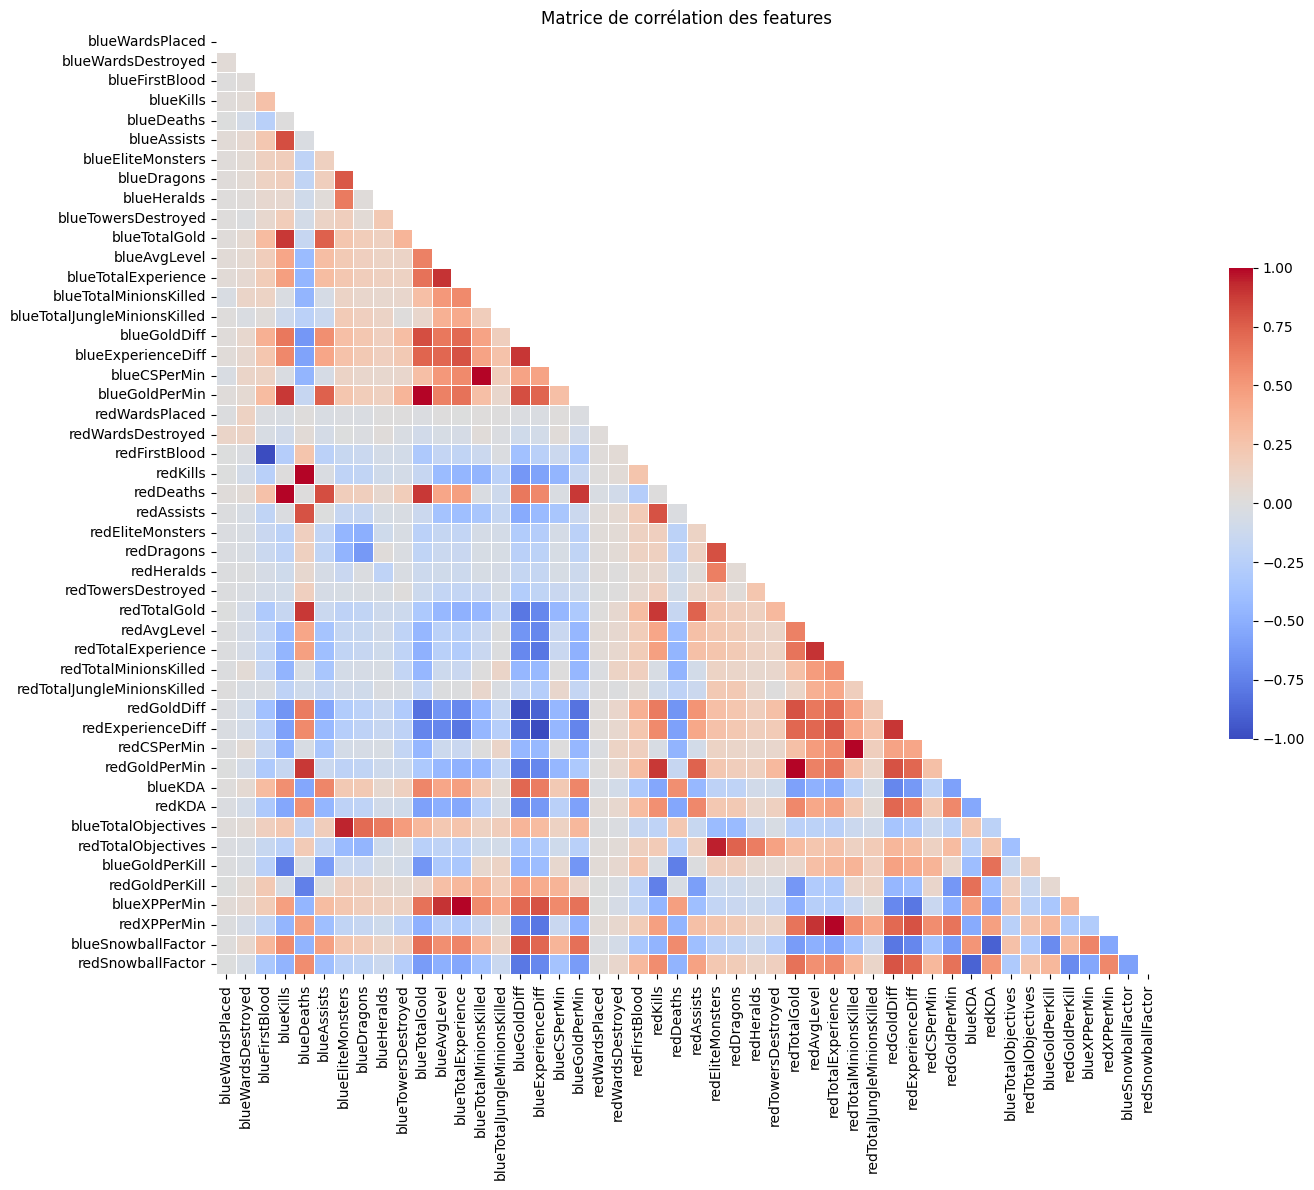

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor


X = df.drop(columns=['gameId', 'blueWins'])

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)

print("Valeurs VIF pour chaque feature :")
print(vif_data.head(20))

plt.figure(figsize=(16, 12))
correlation_matrix = X.corr()

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(correlation_matrix, mask=mask, cmap='coolwarm', center=0, 
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

plt.title('Matrice de corrélation des features')
plt.tight_layout()
plt.show()